# Experiments report: every run, every config, side by side

Reads **everything under `outputs/experiments/`** -- no single run folder to pick, nothing is trained or written.
It walks the run folders (`<name>/<config hash>/seed<k>/`), so new runs show up on the next *Run all*, and runs that
crashed or are still training are listed too.

1. **Inventory** -- every run: status, how it stopped, best epoch, val scores; and what differs between the configs.
2. **Validation summary** -- each config averaged over its seeds (mean ± std). Choose between configs here.
3. **Test summary** -- overall, sharp vs soft kernel (the cross-kernel gap), per scanner. Report the chosen config here.
4. **Training curves** -- all configs on one axis: is the epoch budget enough, does a config over-fit?
5. **Per finding** -- which of the 18 findings each config helps or hurts.
6. **One run in detail** -- learning curves, per-label val results, thresholds and test results of one run.
7. **Save the tables** -- optional CSV export for the thesis / slides.

A config is named by its hash plus the settings where it **departs from the most common value** (`loss=asl`,
`max_epochs=30, patience=30`); the one that departs from nothing is the `reference`. Give configs your own names in
`NICKNAMES`.

In [1]:
import os
import textwrap
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# run from the repository root, wherever the notebook was opened
root = Path.cwd().resolve()
while not (root / "configs" / "preprocessing.yaml").exists() and root != root.parent:
    root = root.parent
os.chdir(root)

from ct_model.training.results import load_results, mean_std, pm

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 80)

## Settings

- `OUTPUT_DIR`: the experiments folder. A sub-folder works too (one experiment name, one config hash, one seed).
- `NICKNAMES`: optional readable names, keyed by the first 8 characters of the config hash. Configs not listed get the
  automatic label.
- `REFERENCE`: the config the others are compared against (`Δ` columns). `None` = the best on val macro AUROC.

In [2]:
OUTPUT_DIR = "outputs/experiments"
NICKNAMES = {
    "da82a90e": "per-label ABMIL, BCE, 30 ep",
    "cae0b8e1": "per-label ABMIL, BCE, 100 ep",
    "343abb47": "per-label ABMIL, weighted BCE",
    "3e8a8f11": "mean pool, BCE",
    "d5a85e2a": "single ABMIL, BCE",
    "c456aae5": "per-label ABMIL, ASL",
}
REFERENCE = None  # e.g. "da82a90e"

res = load_results(OUTPUT_DIR)
runs = res.runs.copy()
runs["label"] = [f"{h}  {NICKNAMES.get(h, s)}" for h, s in zip(runs.hash8, runs.setup)]
LABEL = dict(zip(runs.config_hash, runs.label))
for frame in (res.curves, res.val_labels, res.test, res.test_labels):
    if len(frame):
        frame["label"] = frame.config_hash.map(LABEL)

# configs ordered best first on val, one colour each for every chart below
order = runs.groupby("label").val_macro_auroc.mean().sort_values(ascending=False).index.tolist()
COLOR = dict(zip(order, plt.cm.tab10.colors))
ref_label = next((l for l in order if l.startswith(REFERENCE)), order[0]) if REFERENCE else order[0]
print(f"{len(runs)} runs of {len(order)} configs under {OUTPUT_DIR}; reference: {ref_label}")


def styled(df, high=(), low=(), fmt="{:.4f}"):
    """Table with the best value of each `high` (larger is better) / `low` column in bold green."""
    s = df.style.format(fmt, subset=df.select_dtypes("number").columns.difference(["seeds", "n"]))
    if len(high):
        s = s.highlight_max(subset=list(high), props="font-weight:bold; color:#1a7f37")
    if len(low):
        s = s.highlight_min(subset=list(low), props="font-weight:bold; color:#1a7f37")
    return s


def short(label, width=44):
    return label if len(label) <= width else label[: width - 1] + "…"


def wrap(label, width=18):
    return textwrap.fill(label, width)

30 runs of 6 configs under outputs/experiments; reference: da82a90e  per-label ABMIL, BCE, 30 ep


## 1. Inventory

One row per run folder. `stopped` is why training ended (`early_stopping` or `max_epochs`); a best epoch in the last
10 % of `max_epochs` means the curve was still rising and the budget may be too small.

In [3]:
evaluated = set(res.test.run_id) if len(res.test) else set()
inv = runs.copy()
inv["test"] = np.where(inv.run_id.isin(evaluated), "yes", "")
inv["late best"] = np.where(inv.best_epoch > 0.9 * inv.max_epochs, "⚠", "")
inv = inv.set_index("run_id")[["label", "seed", "status", "stopped", "best_epoch", "epochs_run", "max_epochs",
                               "late best", "val_macro_auroc", "val_macro_auprc", "val_micro_auroc",
                               "val_macro_f1", "test"]]
display(styled(inv.sort_values(["label", "seed"]), high=["val_macro_auroc", "val_macro_auprc"]))

not_done = runs[runs.status != "finished"]
if len(not_done):
    print("not finished:", ", ".join(f"{r} ({s})" for r, s in zip(not_done.run_id, not_done.status)))
print("\nwhat differs between the configs (empty = setting not used by that config):")
display(res.settings.rename(index=lambda h: LABEL.get(h, h)).loc[order].fillna(""))

,label,seed,status,stopped,best_epoch,epochs_run,max_epochs,late best,val_macro_auroc,val_macro_auprc,val_micro_auroc,val_macro_f1,test
run_id,,,,,,,,,,,,,
abmil_perlabel_dale2s/343abb47/seed0,"343abb47 per-label ABMIL, weighted BCE",0.0000,finished,early_stopping,19.0000,34.0000,100.0000,,0.8052,0.4816,0.8175,0.5122,
abmil_perlabel_dale2s/343abb47/seed1,"343abb47 per-label ABMIL, weighted BCE",1.0000,finished,early_stopping,20.0000,35.0000,100.0000,,0.8043,0.4765,0.8227,0.5084,
abmil_perlabel_dale2s/343abb47/seed2,"343abb47 per-label ABMIL, weighted BCE",2.0000,finished,early_stopping,15.0000,30.0000,100.0000,,0.8062,0.4809,0.8194,0.5138,
abmil_perlabel_dale2s/343abb47/seed3,"343abb47 per-label ABMIL, weighted BCE",3.0000,finished,early_stopping,13.0000,28.0000,100.0000,,0.8026,0.4757,0.8178,0.5070,
abmil_perlabel_dale2s/343abb47/seed4,"343abb47 per-label ABMIL, weighted BCE",4.0000,finished,early_stopping,22.0000,37.0000,100.0000,,0.8054,0.4811,0.8252,0.5112,
meanpool_dale2s/3e8a8f11/seed0,"3e8a8f11 mean pool, BCE",0.0000,finished,early_stopping,32.0000,47.0000,100.0000,,0.8041,0.4758,0.8475,0.5172,yes
meanpool_dale2s/3e8a8f11/seed1,"3e8a8f11 mean pool, BCE",1.0000,finished,early_stopping,25.0000,40.0000,100.0000,,0.8045,0.4752,0.8466,0.5116,yes
meanpool_dale2s/3e8a8f11/seed2,"3e8a8f11 mean pool, BCE",2.0000,finished,early_stopping,29.0000,44.0000,100.0000,,0.8039,0.4741,0.8470,0.5141,yes
meanpool_dale2s/3e8a8f11/seed3,"3e8a8f11 mean pool, BCE",3.0000,finished,early_stopping,23.0000,38.0000,100.0000,,0.8038,0.4747,0.8469,0.5090,yes



what differs between the configs (empty = setting not used by that config):


,aggregator.type,aggregator.branches,loss.type,optim.max_epochs,optim.patience
"da82a90e per-label ABMIL, BCE, 30 ep",abmil,per_label,bce,30,30
"cae0b8e1 per-label ABMIL, BCE, 100 ep",abmil,per_label,bce,100,15
"343abb47 per-label ABMIL, weighted BCE",abmil,per_label,weighted_bce,100,15
"3e8a8f11 mean pool, BCE",mean_pool,,bce,100,15
"d5a85e2a single ABMIL, BCE",abmil,single,bce,100,15
"c456aae5 per-label ABMIL, ASL",abmil,per_label,asl,100,15


## 2. Validation summary

Mean ± std over seeds. **This is where configs are compared** -- the test set is kept for reporting the chosen one.
`Δ` columns are the difference to the reference config, in AUROC points ×100 (so `-0.35` means 0.0035 lower). A
difference smaller than the seed std is noise.

,seeds,val_macro_auroc,val_macro_auprc,val_micro_auroc,val_macro_f1,best_epoch,best_epoch_std,Δ macro_auroc ×100,Δ macro_auprc ×100
label,,,,,,,,,
"da82a90e per-label ABMIL, BCE, 30 ep",5,0.8083 ± 0.0005,0.4847 ± 0.0015,0.8492 ± 0.0011,0.5172 ± 0.0010,18.4,3.0,0.00,0.00
"cae0b8e1 per-label ABMIL, BCE, 100 ep",5,0.8072 ± 0.0008,0.4833 ± 0.0023,0.8475 ± 0.0009,0.5149 ± 0.0013,14.6,3.4,-0.10,-0.14
"343abb47 per-label ABMIL, weighted BCE",5,0.8047 ± 0.0014,0.4792 ± 0.0028,0.8205 ± 0.0033,0.5105 ± 0.0028,17.8,3.7,-0.36,-0.56
"3e8a8f11 mean pool, BCE",5,0.8040 ± 0.0003,0.4745 ± 0.0012,0.8470 ± 0.0003,0.5132 ± 0.0031,26.2,4.2,-0.43,-1.02
"d5a85e2a single ABMIL, BCE",5,0.8019 ± 0.0007,0.4743 ± 0.0028,0.8440 ± 0.0011,0.5109 ± 0.0039,10.0,1.6,-0.64,-1.05
"c456aae5 per-label ABMIL, ASL",5,0.8000 ± 0.0012,0.4704 ± 0.0038,0.8410 ± 0.0012,0.5092 ± 0.0020,16.8,3.5,-0.83,-1.44


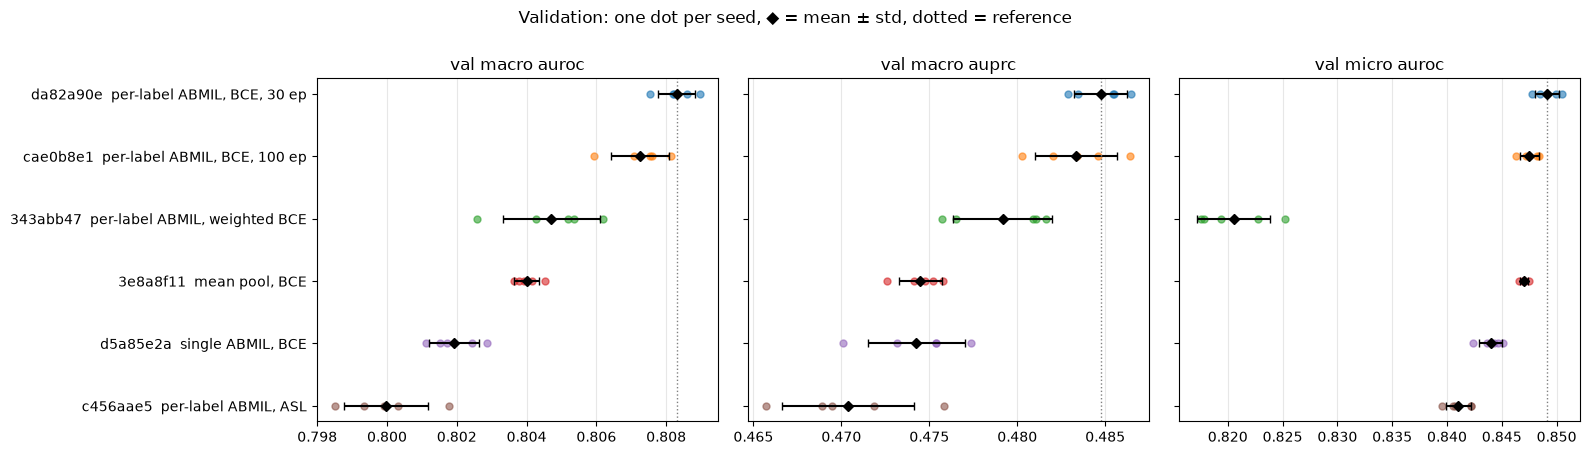

In [4]:
VAL = ["val_macro_auroc", "val_macro_auprc", "val_micro_auroc", "val_macro_f1", "best_epoch"]
val = mean_std(runs, ["label"], VAL).loc[order]
val_tab = pm(val, VAL[:-1]).join(val[["best_epoch", "best_epoch_std"]].round(1))
for m in ["val_macro_auroc", "val_macro_auprc"]:
    val_tab[f"Δ {m.removeprefix('val_')} ×100"] = ((val[m] - val.loc[ref_label, m]) * 100).round(2)
display(val_tab)

fig, axes = plt.subplots(1, 3, figsize=(16, 0.45 * len(order) + 1.8), sharey=True)
for ax, m in zip(axes, ["val_macro_auroc", "val_macro_auprc", "val_micro_auroc"]):
    for y, lab in enumerate(order):
        pts = runs.loc[runs.label == lab, m]
        ax.scatter(pts, [y] * len(pts), color=COLOR[lab], alpha=0.6, s=25)
        ax.errorbar(pts.mean(), y, xerr=pts.std(), fmt="D", color="black", ms=5, capsize=3)
    ax.axvline(runs.loc[runs.label == ref_label, m].mean(), color="gray", ls=":", lw=1)
    ax.set_title(m.replace("_", " ")); ax.grid(axis="x", alpha=0.3)
axes[0].set_yticks(range(len(order)), [short(l) for l in order]); axes[0].invert_yaxis()
fig.suptitle("Validation: one dot per seed, ◆ = mean ± std, dotted = reference", y=1.0)
plt.tight_layout(); plt.show()

## 3. Test summary

Only configs evaluated with `scripts/model/evaluate_mil.py`. Thresholds were chosen on val. Training saw only sharp
kernels, so **soft − sharp** is the cross-kernel gap (negative = worse on the unseen kernel). The `other` kernel group
(36 volumes) is too small to read on its own. `CI` is the mean of the per-seed 95 % bootstrap interval of the overall
macro AUROC.

test volumes per kernel: {'other': 36, 'sharp': 1542, 'soft': 1459}


,,seeds,overall,sharp,soft,soft - sharp,auprc,micro_auroc,macro_f1,CI (overall)
label,eval,,,,,,,,,
"da82a90e per-label ABMIL, BCE, 30 ep",ctrate__train-sharp-5800__test,5,0.7929 ± 0.0028,0.8129 ± 0.0007,0.7976 ± 0.0010,-0.0152 ± 0.0006,0.4897 ± 0.0039,0.8270 ± 0.0016,0.4959 ± 0.0092,"[0.784, 0.802]"
"3e8a8f11 mean pool, BCE",ctrate__train-sharp-5800__test,5,0.7820 ± 0.0028,0.8084 ± 0.0011,0.7861 ± 0.0023,-0.0223 ± 0.0016,0.4697 ± 0.0029,0.8158 ± 0.0014,0.4817 ± 0.0016,"[0.774, 0.791]"
"d5a85e2a single ABMIL, BCE",ctrate__train-sharp-5800__test,5,0.7902 ± 0.0018,0.8074 ± 0.0009,0.7957 ± 0.0013,-0.0116 ± 0.0020,0.4801 ± 0.0018,0.8246 ± 0.0018,0.4931 ± 0.0042,"[0.782, 0.799]"


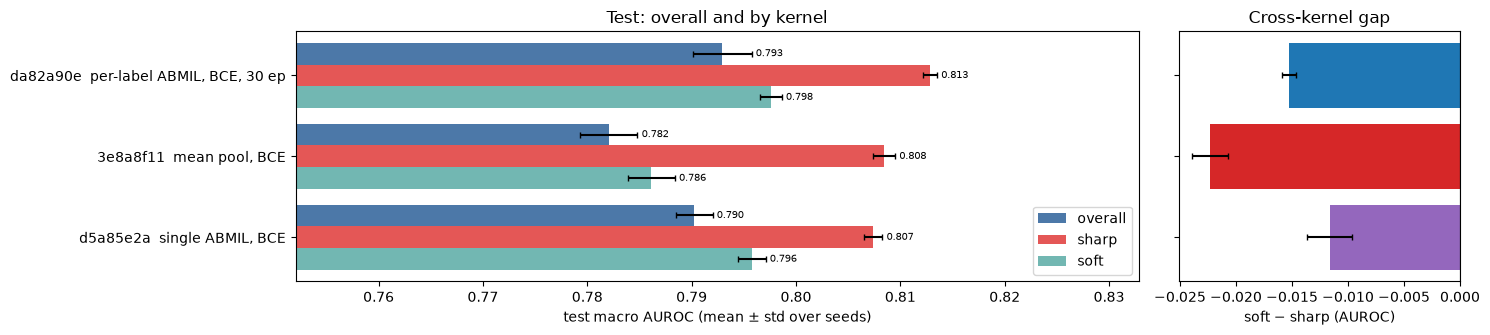

test macro AUROC by scanner (mean over seeds)


,PNMS (n=140),Philips (n=1927),SIEMENS (n=120),Siemens Healthineers (n=850)
label,,,,
"da82a90e per-label ABMIL, BCE, 30 ep",0.8116,0.7967,0.7511,0.7812
"3e8a8f11 mean pool, BCE",0.8141,0.7846,0.7331,0.7714
"d5a85e2a single ABMIL, BCE",0.8004,0.7927,0.7484,0.7818


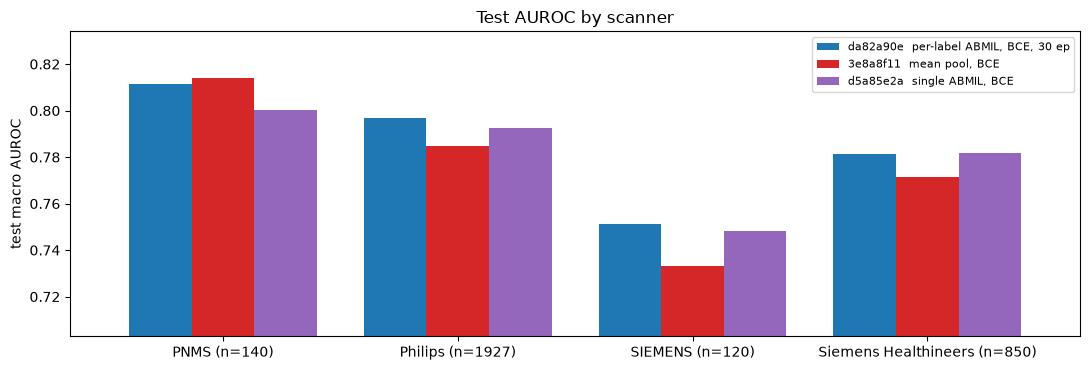

In [5]:
test = res.test[res.test.eval_split == "test"] if len(res.test) else res.test
if test.empty:
    print("no test evaluation yet -- python scripts/model/evaluate_mil.py --experiment-dir <run folder>")
else:
    def pick(group_by, group, metric):
        part = test[(test.group_by == group_by) & (test.group == group)]
        return part.set_index(["label", "eval", "run_id"])[metric]

    per_run = pd.DataFrame({
        "overall": pick("all", "all", "macro_auroc"), "sharp": pick("kernel_class", "sharp", "macro_auroc"),
        "soft": pick("kernel_class", "soft", "macro_auroc"), "auprc": pick("all", "all", "macro_auprc"),
        "micro_auroc": pick("all", "all", "micro_auroc"), "macro_f1": pick("all", "all", "macro_f1"),
        "ci_low": pick("all", "all", "macro_auroc_ci_low"), "ci_high": pick("all", "all", "macro_auroc_ci_high"),
    }).reset_index()
    per_run["soft - sharp"] = per_run.soft - per_run.sharp
    TEST = ["overall", "sharp", "soft", "soft - sharp", "auprc", "micro_auroc", "macro_f1"]
    tst = mean_std(per_run, ["label", "eval"], TEST + ["ci_low", "ci_high"])
    tst = tst.loc[[i for l in order for i in tst.index if i[0] == l]]
    tst_tab = pm(tst, TEST)
    tst_tab["CI (overall)"] = [f"[{a:.3f}, {b:.3f}]" for a, b in zip(tst.ci_low, tst.ci_high)]
    n = test[test.group_by == "kernel_class"].groupby("group").n_volumes.first()
    print("test volumes per kernel:", n.to_dict())
    display(tst_tab)

    labs = [l for l, _ in tst.index]
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 0.55 * len(labs) + 1.8), sharey=True,
                                 gridspec_kw={"width_ratios": [3, 1]})
    y, h = np.arange(len(labs)), 0.27
    for k, (col, colr) in enumerate([("overall", "#4C78A8"), ("sharp", "#E45756"), ("soft", "#72B7B2")]):
        bars = a1.barh(y + (k - 1) * h, tst[col], h, xerr=tst[f"{col}_std"], color=colr, label=col, capsize=2)
        a1.bar_label(bars, fmt="%.3f", fontsize=7, padding=3)
    lo = tst[["overall", "sharp", "soft"]].min().min()
    a1.set_xlim(lo - 0.03, tst[["overall", "sharp", "soft"]].max().max() + 0.02)
    a1.set_yticks(y, [short(l) for l in labs]); a1.invert_yaxis()
    a1.set_xlabel("test macro AUROC (mean ± std over seeds)"); a1.legend(loc="lower right")
    a1.set_title("Test: overall and by kernel")
    a2.barh(y, tst["soft - sharp"], xerr=tst["soft - sharp_std"], color=[COLOR[l] for l in labs], capsize=2)
    a2.axvline(0, color="black", lw=0.8); a2.set_xlabel("soft − sharp (AUROC)"); a2.set_title("Cross-kernel gap")
    plt.tight_layout(); plt.show()

    # by scanner
    scan = test[test.group_by == "manufacturer"].groupby(["label", "group"]).agg(
        auroc=("macro_auroc", "mean"), std=("macro_auroc", "std"), n=("n_volumes", "first"),
        too_small=("too_small", "first")).reset_index()
    scan_tab = scan.pivot(index="label", columns="group", values="auroc").loc[labs]
    scan_tab.columns = [f"{g} (n={scan[scan.group == g].n.iloc[0]})" for g in scan_tab.columns]
    print("test macro AUROC by scanner (mean over seeds)")
    display(styled(scan_tab, high=scan_tab.columns))
    ax = scan_tab.T.plot.bar(figsize=(11, 3.8), width=0.8, color=[COLOR[l] for l in labs])
    ax.set_ylim(scan_tab.min().min() - 0.03, scan_tab.max().max() + 0.02); ax.set_ylabel("test macro AUROC")
    ax.set_title("Test AUROC by scanner"); ax.legend([short(l) for l in labs], fontsize=8)
    plt.xticks(rotation=0); plt.tight_layout(); plt.show()

## 4. Training curves

Mean over seeds (line) with the range over seeds (band); the dashed vertical line is the mean best epoch. A config
whose val AUROC is still rising when the curve ends has too small an epoch budget; val loss rising while train loss
keeps falling is over-fitting. Seeds that stopped early drop out of the mean, so the end of a curve may rest on fewer
seeds.

BCE, weighted BCE and ASL are on different scales, so the losses are drawn **relative**: val loss divided by that run's
lowest val loss (1.0 = its best; above 1 = getting worse), train loss divided by its first-epoch value.

The learning rate follows a warm-up + cosine schedule that ends at `max_epochs`. `lr left at stop` is the learning rate at
the last epoch as a share of its peak: a run that early-stops with most of its learning rate left never reached the
low-LR end of its schedule, so it is compared with a config that did on unequal terms.

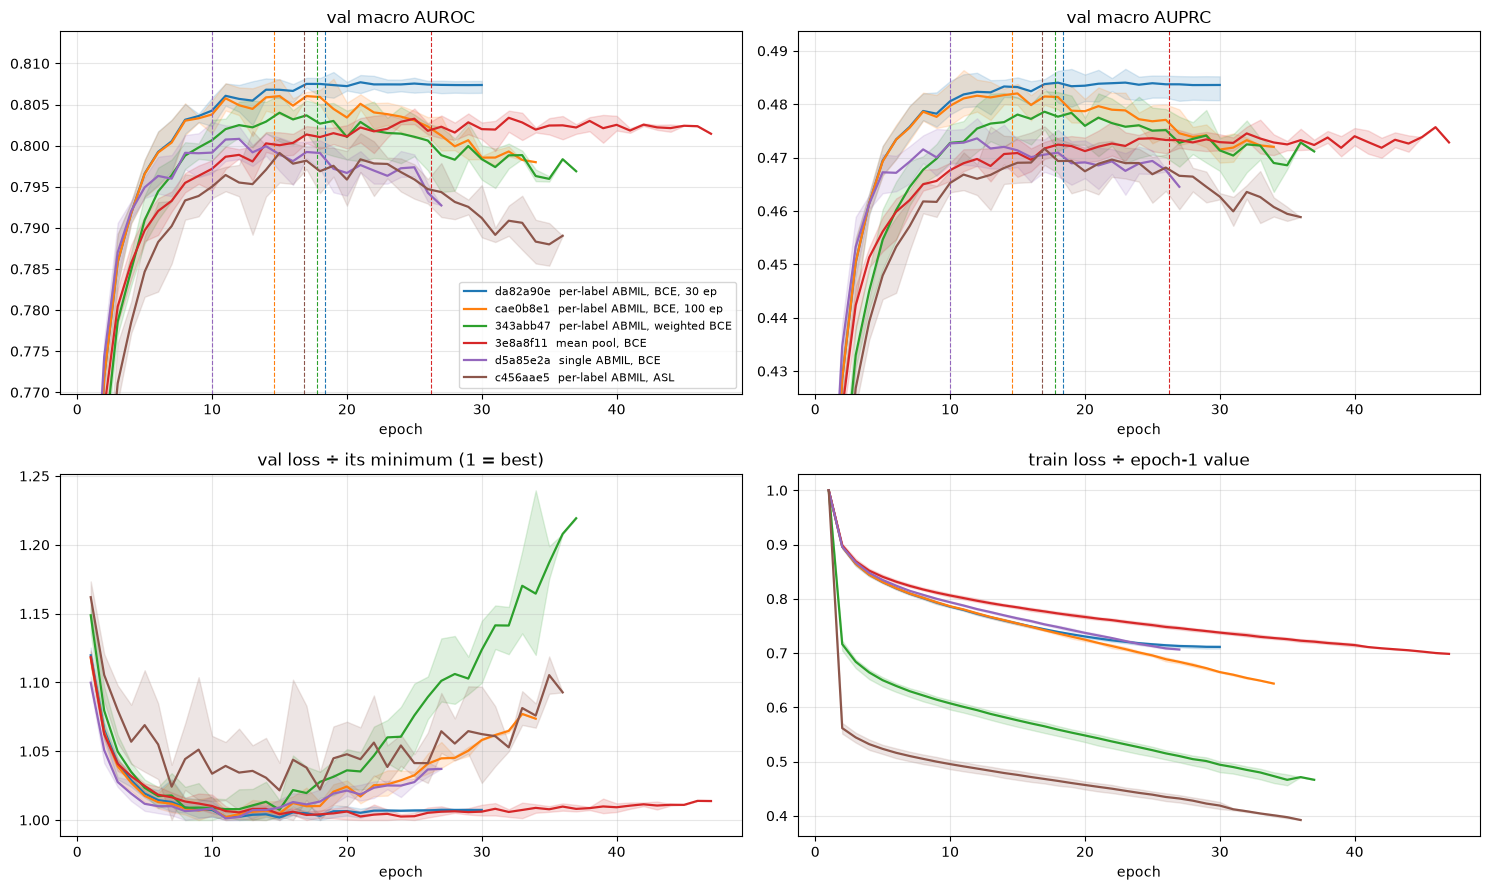

,seconds_per_epoch,lr left at stop %,epochs_run,max_epochs,best_epoch,early_stopped,minutes_per_run
label,,,,,,,
"da82a90e per-label ABMIL, BCE, 30 ep",3.51,0.00,30.0,30,18.4,0/5,1.8
"cae0b8e1 per-label ABMIL, BCE, 100 ep",3.51,81.53,29.6,100,14.6,5/5,1.7
"343abb47 per-label ABMIL, weighted BCE",3.48,77.39,32.8,100,17.8,5/5,1.9
"3e8a8f11 mean pool, BCE",3.39,65.34,41.2,100,26.2,5/5,2.3
"d5a85e2a single ABMIL, BCE",3.52,86.98,25.0,100,10.0,5/5,1.5
"c456aae5 per-label ABMIL, ASL",3.59,78.73,31.8,100,16.8,5/5,1.9


In [6]:
cur = res.curves.copy()
cur["val_loss_rel"] = cur.val_loss / cur.groupby("run_id").val_loss.transform("min")
cur["train_loss_rel"] = cur.train_loss / cur.groupby("run_id").train_loss.transform("first")
METRICS = [("val_macro_auroc", "val macro AUROC"), ("val_macro_auprc", "val macro AUPRC"),
           ("val_loss_rel", "val loss ÷ its minimum (1 = best)"), ("train_loss_rel", "train loss ÷ epoch-1 value")]
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for ax, (m, title) in zip(axes.flat, METRICS):
    for lab in order:
        g = cur[cur.label == lab].groupby("epoch")[m].agg(["mean", "min", "max"])
        ax.plot(g.index, g["mean"], color=COLOR[lab], label=short(lab), lw=1.6)
        ax.fill_between(g.index, g["min"], g["max"], color=COLOR[lab], alpha=0.15)
        if m.startswith("val_macro"):
            ax.axvline(runs.loc[runs.label == lab, "best_epoch"].mean(), color=COLOR[lab], ls="--", lw=0.8)
    ax.set_title(title); ax.set_xlabel("epoch"); ax.grid(alpha=0.3)
axes[0, 0].set_ylim(bottom=cur.val_macro_auroc.quantile(0.05))
axes[0, 1].set_ylim(bottom=cur.val_macro_auprc.quantile(0.05))
axes[0, 0].legend(fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

last = cur.sort_values("epoch").groupby("run_id").agg(label=("label", "first"), lr_last=("lr", "last"), lr_peak=("lr", "max"))
lr_left = (100 * last.lr_last / last.lr_peak).groupby(last.label).mean().rename("lr left at stop %")
timing = cur.groupby("label").agg(seconds_per_epoch=("seconds", "mean")).join(lr_left).join(
    runs.groupby("label").agg(epochs_run=("epochs_run", "mean"), max_epochs=("max_epochs", "first"),
                              best_epoch=("best_epoch", "mean"),
                              early_stopped=("stopped", lambda s: f"{(s == 'early_stopping').sum()}/{len(s)}"))).loc[order]
timing["minutes_per_run"] = (timing.seconds_per_epoch * timing.epochs_run / 60).round(1)
display(timing.round(2))

## 5. Per finding

Val AUROC of every finding, mean over seeds (left), and the difference to the reference config (right, ×100; green =
better than the reference). Findings are sorted by the reference's AUROC, hardest at the bottom. A config can win on
average while losing on the rare findings -- this is where that shows.

label,"da82a90e per-label ABMIL, BCE, 30 ep","cae0b8e1 per-label ABMIL, BCE, 100 ep","343abb47 per-label ABMIL, weighted BCE","3e8a8f11 mean pool, BCE","d5a85e2a single ABMIL, BCE","c456aae5 per-label ABMIL, ASL",positives (val)
finding,,,,,,,
Pleural effusion,0.9736,0.9730,0.9715,0.9722,0.9742,0.9735,122
Cardiomegaly,0.9363,0.9353,0.9329,0.9272,0.9294,0.9309,112
Arterial wall calcification,0.9108,0.9097,0.9064,0.9142,0.9061,0.9091,301
Coronary artery wall calcification,0.8935,0.8917,0.8898,0.8971,0.8871,0.8937,273
Medical material,0.8554,0.8536,0.8417,0.8483,0.8389,0.8455,110
Mosaic attenuation pattern,0.8438,0.8421,0.8458,0.8503,0.8266,0.8501,80
Consolidation,0.8408,0.8408,0.8361,0.8216,0.8323,0.8110,207
Pericardial effusion,0.8376,0.8346,0.8296,0.8198,0.8363,0.8217,75
Interlobular septal thickening,0.8228,0.8225,0.8101,0.8042,0.8241,0.7979,85


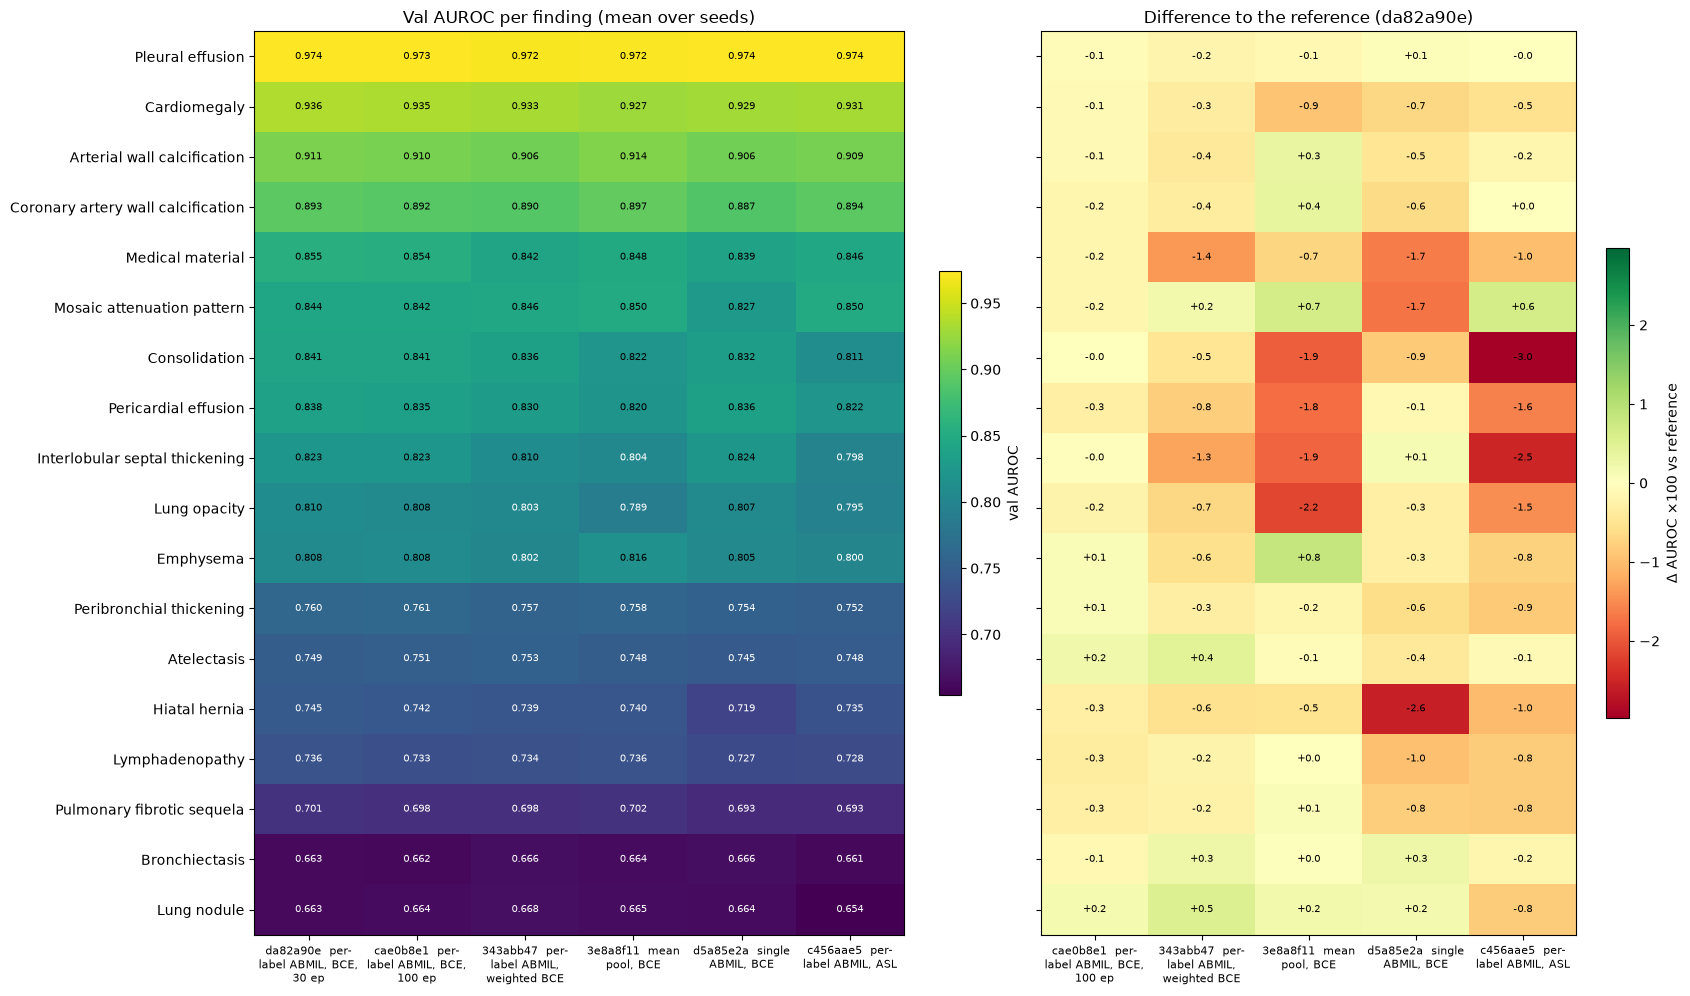

findings where each config beats the reference: {'cae0b8e1  per-label ABMIL, BCE, 100 ep': 4, '343abb47  per-label ABMIL, weighted BCE': 4, '3e8a8f11  mean pool, BCE': 8, 'd5a85e2a  single ABMIL, BCE': 4, 'c456aae5  per-label ABMIL, ASL': 2}


In [7]:
def nice(name):
    return name.replace("_", " ").capitalize()

vl = res.val_labels.pivot_table(index="finding", columns="label", values="auroc", aggfunc="mean")[order]
vl = vl.sort_values(ref_label, ascending=False).rename(index=nice)
delta = vl.sub(vl[ref_label], axis=0).drop(columns=ref_label) * 100
prev = res.val_labels.groupby("finding").n_pos.first().rename(index=nice)
display(styled(vl.assign(**{"positives (val)": prev}), high=order).format("{:.0f}", subset=["positives (val)"]))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(17, 0.42 * len(vl) + 2.5),
                             gridspec_kw={"width_ratios": [len(order), max(len(order) - 1, 1)]})
im = a1.imshow(vl.to_numpy(), cmap="viridis", aspect="auto")
a1.set_xticks(range(len(order)), [wrap(l) for l in order], fontsize=8)
a1.set_yticks(range(len(vl)), vl.index)
for i in range(vl.shape[0]):
    for j in range(vl.shape[1]):
        a1.text(j, i, f"{vl.iat[i, j]:.3f}", ha="center", va="center", fontsize=7,
                color="black" if vl.iat[i, j] > vl.to_numpy().mean() else "white")
fig.colorbar(im, ax=a1, fraction=0.03, label="val AUROC")
a1.set_title("Val AUROC per finding (mean over seeds)")
lim = max(np.abs(delta.to_numpy()).max(), 0.5)
im2 = a2.imshow(delta.to_numpy(), cmap="RdYlGn", vmin=-lim, vmax=lim, aspect="auto")
a2.set_xticks(range(delta.shape[1]), [wrap(l) for l in delta.columns], fontsize=8)
a2.set_yticks(range(len(delta)), [])
for i in range(delta.shape[0]):
    for j in range(delta.shape[1]):
        a2.text(j, i, f"{delta.iat[i, j]:+.1f}", ha="center", va="center", fontsize=7)
fig.colorbar(im2, ax=a2, fraction=0.04, label="Δ AUROC ×100 vs reference")
a2.set_title(f"Difference to the reference ({ref_label[:8]})")
plt.tight_layout(); plt.show()
print("findings where each config beats the reference:", (delta > 0).sum().to_dict())

### Per finding on test: sharp vs soft

For every evaluated config: test AUROC per finding on the sharp and the soft volumes (mean over seeds). Findings with
the largest drop on soft are the ones that do not transfer to the unseen kernel.

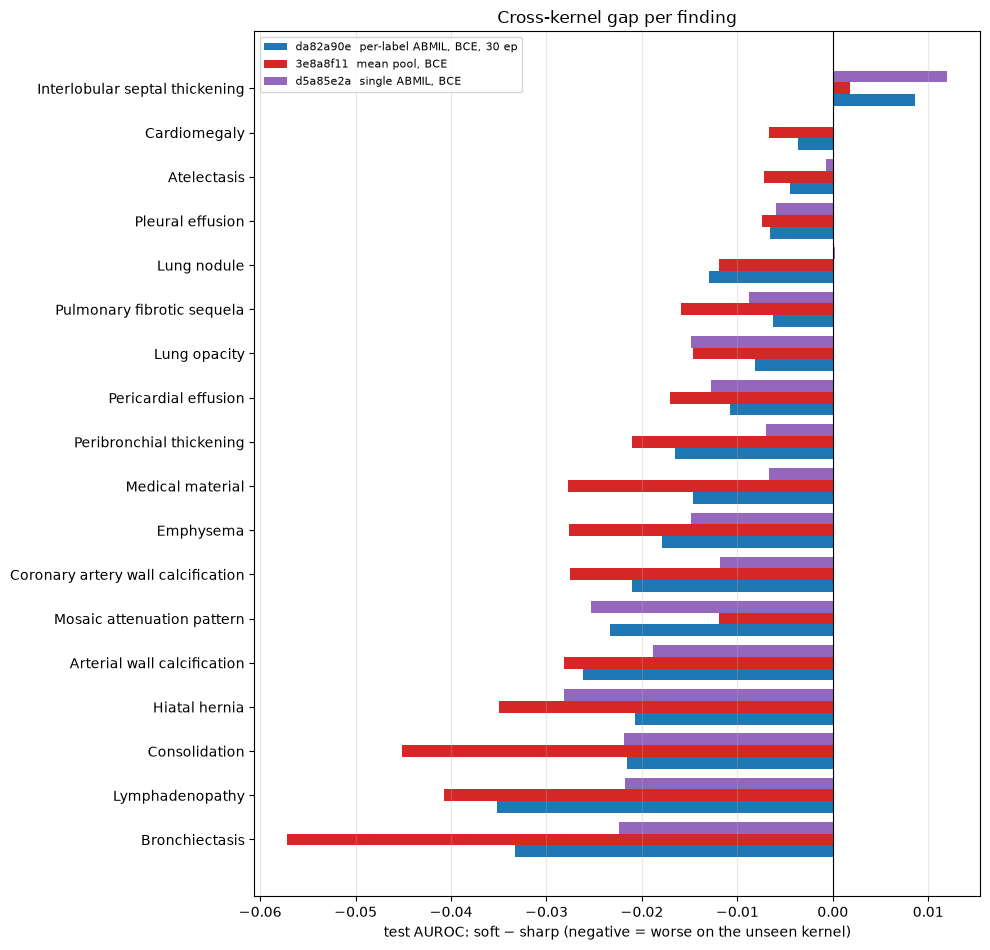

In [8]:
if res.test_labels.empty:
    print("no test evaluation yet")
else:
    tl = res.test_labels[(res.test_labels.eval_split == "test") & (res.test_labels.group_by == "kernel_class")
                         & res.test_labels.group.isin(["sharp", "soft"])]
    tl = tl.pivot_table(index="finding", columns=["label", "group"], values="auroc", aggfunc="mean")
    labs = [l for l in order if l in tl.columns.get_level_values(0)]
    gap = pd.DataFrame({l: tl[(l, "soft")] - tl[(l, "sharp")] for l in labs}).rename(index=nice)
    gap = gap.loc[gap.mean(axis=1).sort_values().index]
    table = pd.concat({short(l, 28): tl[l].rename(index=nice).loc[gap.index] for l in labs}, axis=1)
    for l in labs:
        table[(short(l, 28), "soft - sharp")] = gap[l]
    display(table.sort_index(axis=1, level=0, sort_remaining=False).style.format("{:.3f}")
            .background_gradient(cmap="RdYlGn", subset=[c for c in table.columns if c[1] == "soft - sharp"],
                                 vmin=-0.08, vmax=0.08))

    y, h = np.arange(len(gap)), 0.8 / len(labs)
    fig, ax = plt.subplots(figsize=(10, 0.45 * len(gap) + 1.5))
    for k, l in enumerate(labs):
        ax.barh(y + (k - (len(labs) - 1) / 2) * h, gap[l], h, color=COLOR[l], label=short(l))
    ax.axvline(0, color="black", lw=0.8)
    ax.set_yticks(y, gap.index); ax.set_xlabel("test AUROC: soft − sharp (negative = worse on the unseen kernel)")
    ax.set_title("Cross-kernel gap per finding"); ax.legend(fontsize=8); ax.grid(axis="x", alpha=0.3)
    plt.tight_layout(); plt.show()

## 6. One run in detail

`RUN = None` takes the seed closest to the mean of the best config on val (a typical run, not a lucky one); otherwise
give a run id from the inventory, e.g. `"abmil_perlabel_dale2s/da82a90e/seed0"`.

abmil_perlabel_dale2s/da82a90e/seed1  |  da82a90e  per-label ABMIL, BCE, 30 ep
stopped by max_epochs after 30 of 30 epochs; best epoch 21: val macro AUROC 0.8082, AUPRC 0.4864


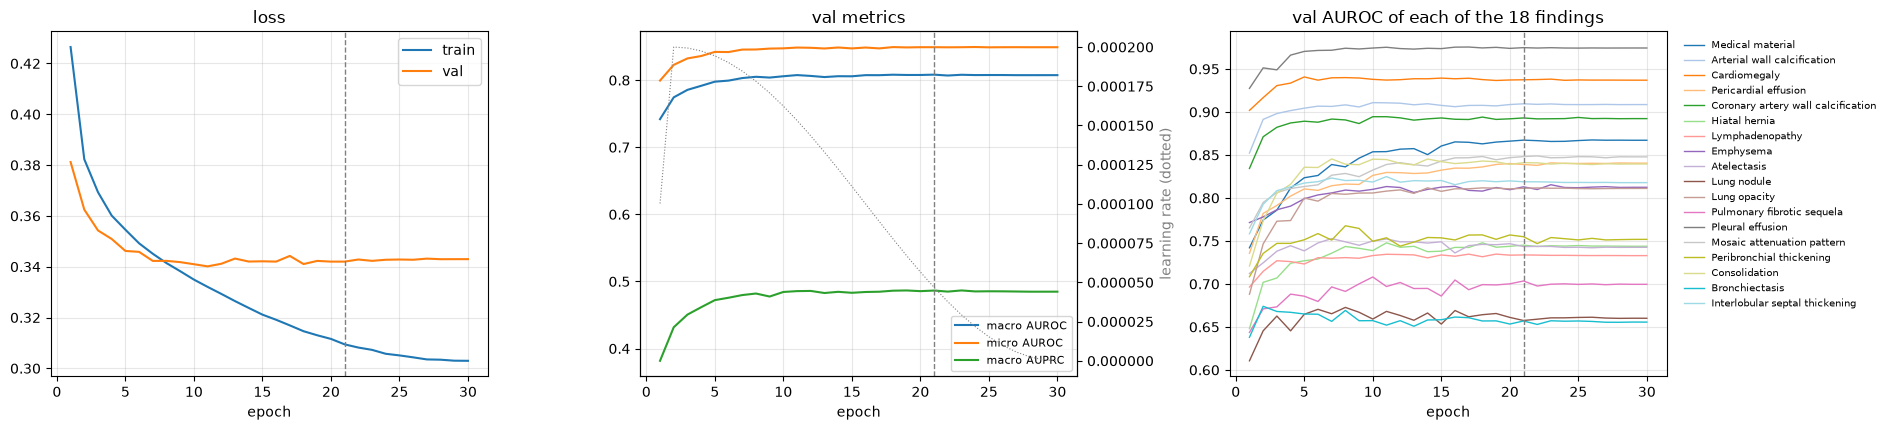

,n_pos,auroc,auprc,threshold,f1,sensitivity,specificity,ppv
finding,,,,,,,,
Pleural effusion,122,0.9748,0.8843,0.3341,0.8069,0.7705,0.9839,0.8468
Cardiomegaly,112,0.9374,0.6536,0.3577,0.6441,0.6786,0.9550,0.6129
Arterial wall calcification,301,0.9095,0.7584,0.3784,0.7163,0.7508,0.8814,0.6848
Coronary artery wall calcification,273,0.8930,0.6938,0.3093,0.6741,0.7766,0.8409,0.5955
Medical material,110,0.8672,0.4671,0.3766,0.4711,0.4818,0.9419,0.4609
Mosaic attenuation pattern,80,0.8481,0.2616,0.1342,0.3704,0.6250,0.8725,0.2632
Consolidation,207,0.8410,0.5362,0.2338,0.5558,0.6618,0.8465,0.4790
Pericardial effusion,75,0.8389,0.2356,0.2169,0.3795,0.4933,0.9248,0.3083
Interlobular septal thickening,85,0.8188,0.2473,0.0961,0.3304,0.6588,0.8188,0.2205


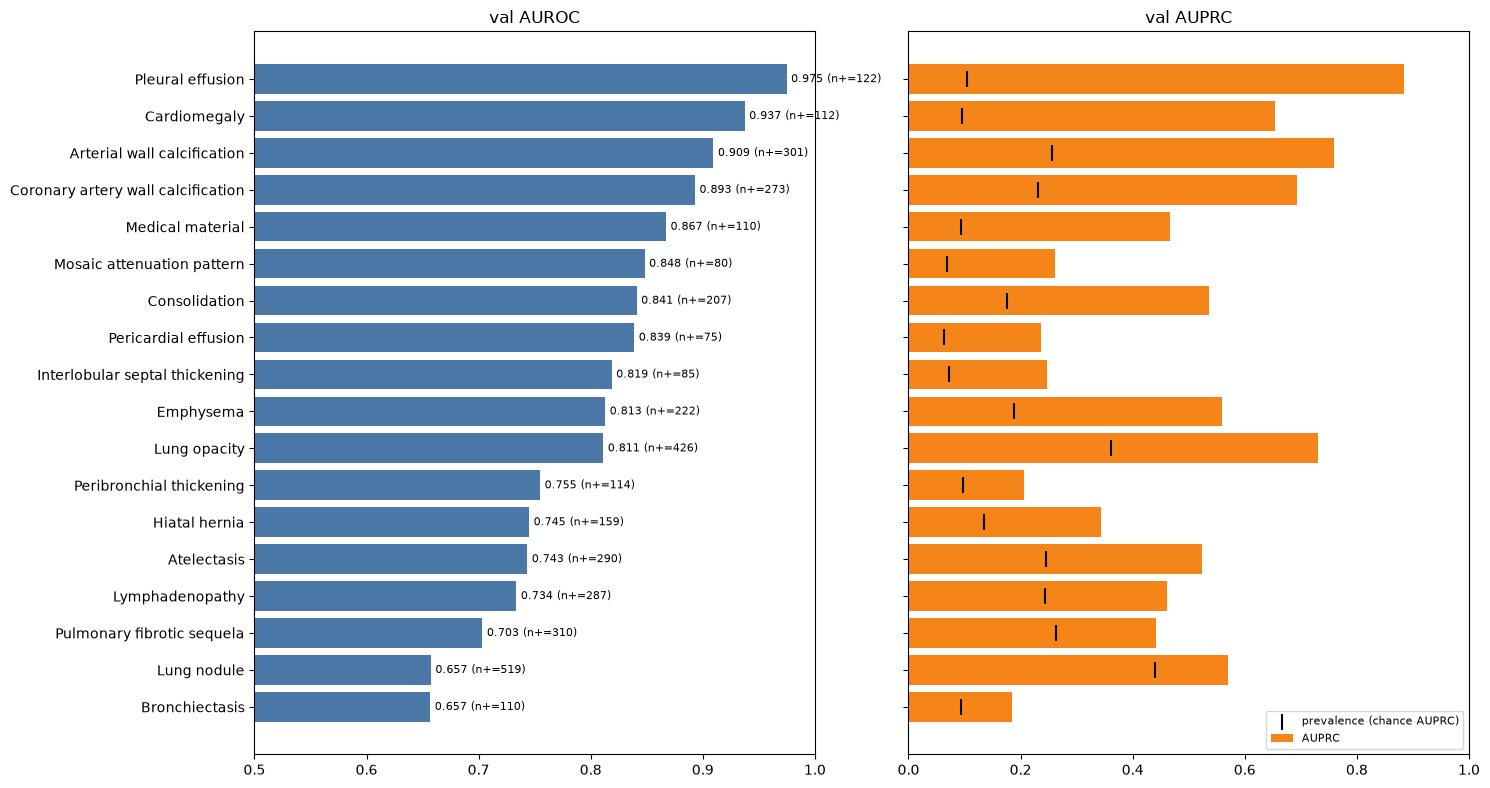

In [9]:
RUN = None

if RUN is None:
    best = runs[runs.label == order[0]]
    RUN = best.loc[(best.val_macro_auroc - best.val_macro_auroc.mean()).abs().idxmin(), "run_id"]
one = runs.set_index("run_id").loc[RUN]
m = res.curves[res.curves.run_id == RUN]
print(f"{RUN}  |  {one.label}\nstopped by {one.stopped} after {one.epochs_run} of {one.max_epochs} epochs; "
      f"best epoch {one.best_epoch}: val macro AUROC {one.val_macro_auroc:.4f}, AUPRC {one.val_macro_auprc:.4f}")

finding_cols = [c for c in m.columns if c.startswith("val_auroc_")]
fig, axes = plt.subplots(1, 3, figsize=(19, 4.4))
axes[0].plot(m.epoch, m.train_loss, label="train"); axes[0].plot(m.epoch, m.val_loss, label="val")
axes[0].set_title("loss"); axes[0].legend()
axes[1].plot(m.epoch, m.val_macro_auroc, label="macro AUROC"); axes[1].plot(m.epoch, m.val_micro_auroc, label="micro AUROC")
axes[1].plot(m.epoch, m.val_macro_auprc, label="macro AUPRC"); axes[1].set_title("val metrics")
cmap = plt.cm.tab20(np.linspace(0, 1, len(finding_cols)))
for c, colr in zip(finding_cols, cmap):
    axes[2].plot(m.epoch, m[c], lw=1, color=colr, label=nice(c.removeprefix("val_auroc_")))
axes[2].set_title(f"val AUROC of each of the {len(finding_cols)} findings")
axes[2].legend(fontsize=7, bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
ax2 = axes[1].twinx(); ax2.plot(m.epoch, m.lr, color="gray", lw=0.8, ls=":", label="learning rate")
ax2.set_ylabel("learning rate (dotted)", color="gray"); axes[1].legend(loc="lower right", fontsize=8)
for a in axes:
    a.axvline(one.best_epoch, color="gray", ls="--", lw=1); a.set_xlabel("epoch"); a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

v = res.val_labels[res.val_labels.run_id == RUN].set_index("finding").rename(index=nice).sort_values("auroc")
display(styled(v[["n_pos", "auroc", "auprc", "threshold", "f1", "sensitivity", "specificity", "ppv"]]
               .sort_values("auroc", ascending=False), high=["auroc", "auprc", "f1"]).format("{:.0f}", subset=["n_pos"]))
fig, ax = plt.subplots(1, 2, figsize=(15, 0.36 * len(v) + 1.5), sharey=True)
ax[0].barh(v.index, v.auroc, color="#4C78A8"); ax[0].set_xlim(0.5, 1); ax[0].set_title("val AUROC")
ax[1].barh(v.index, v.auprc, color="#F58518", label="AUPRC")
ax[1].scatter(v.n_pos / v.n, v.index, color="black", marker="|", s=120, label="prevalence (chance AUPRC)")
ax[1].set_xlim(0, 1); ax[1].set_title("val AUPRC"); ax[1].legend(fontsize=8, loc="lower right")
for y, (a, n_pos) in enumerate(zip(v.auroc, v.n_pos)):
    ax[0].text(a + 0.004, y, f"{a:.3f} (n+={n_pos})", va="center", fontsize=8)
plt.tight_layout(); plt.show()

t1 = res.test[(res.test.run_id == RUN)] if len(res.test) else res.test
if t1.empty:
    print("this run has no test evaluation -- python scripts/model/evaluate_mil.py --experiment-dir", one.dir)
else:
    cols = ["eval", "group_by", "group", "n_volumes", "n_patients", "too_small", "macro_auroc", "macro_auroc_ci_low",
            "macro_auroc_ci_high", "macro_auprc", "micro_auroc", "macro_f1", "macro_sensitivity", "macro_specificity"]
    display(styled(t1[[c for c in cols if c in t1]].set_index(["eval", "group_by", "group"]), high=["macro_auroc"]))

## 7. Save the tables

`SAVE = True` writes the summary tables of this notebook as CSV next to the runs (`<OUTPUT_DIR>/report/`), for the
thesis or slides. Nothing else in `outputs/` is touched.

In [10]:
SAVE = False

if SAVE:
    out = Path(OUTPUT_DIR) / "report"
    out.mkdir(exist_ok=True)
    inv.to_csv(out / "runs.csv")
    val.to_csv(out / "val_summary.csv")
    vl.to_csv(out / "val_auroc_per_finding.csv")
    if not test.empty:
        tst.to_csv(out / "test_summary.csv")
        scan_tab.to_csv(out / "test_auroc_by_scanner.csv")
    print("written to", out)